## Step 1: Import Libraries

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2: Check Dataset Folder

In [24]:
IMAGE_FOLDER = '/content/drive/MyDrive/archive'

print("Folder exists:", os.path.exists(IMAGE_FOLDER))
print("Files:", os.listdir(IMAGE_FOLDER) if os.path.exists(IMAGE_FOLDER) else "FOLDER NOT FOUND")

Folder exists: True
Files: ['008_kingfisher-881594_640.jpg', '003_parrot-3601194_640.jpg', '009_swan-16736_640.jpg', '005_bird-1045954_640.jpg', '006_bird-1905255_640.jpg', '004_kingfisher-2046453_640.jpg', '002_hummingbird-1854225_640.jpg', '001_owl-50267_1280.jpg', '007_bird-2295436_640.jpg', '011_swan-2350668_640.jpg', '010_dove-2516641_640.jpg', '117_plumage-176723_1280.jpg', '052_peacock-feathers-3013486_640.jpg', '168_hummingbird-2139279_1280.jpg', '111_beach-832346_1280.jpg', '096_european-robin-isolated-on-white-background.jpg', '119_bird-386725_1280.jpg', '062_bird-4051412_640.jpg', '134_winter-843578_1280.jpg', '184_kingfisher-1850226_1280.jpg', '160_eagle-1072696_1280.jpg', '129_hummingbird-2139278_1280.jpg', '085_gulls-370012_640.jpg', '090_bird-3183441_640.jpg', '128_white-tailed-eagle-2015098_1280.jpg', '078_red-kite-50498_640.jpg', '137_eagle-2045655_1280.jpg', '150_grey-crowned-cranes-540657_1280.jpg', '095_starling-in-autumn.jpg', '068_bald-eagle-521492_640.jpg', '127_

## Step 3: Load Image

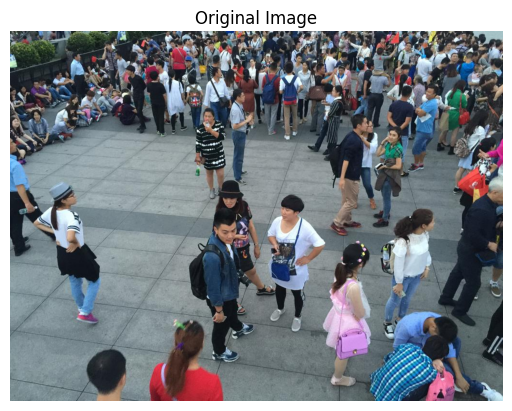

In [25]:
img = cv2.imread('/content/drive/MyDrive/archive/ShanghaiTech/part_B/train_data/images/IMG_10.jpg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

## Step 4: Grayscale Conversion

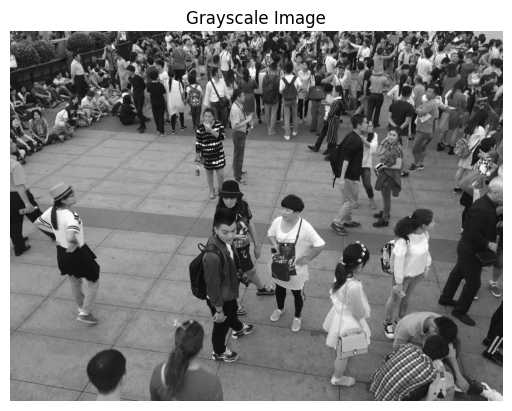

In [26]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

## Step 5: Resize and Gaussian Blur

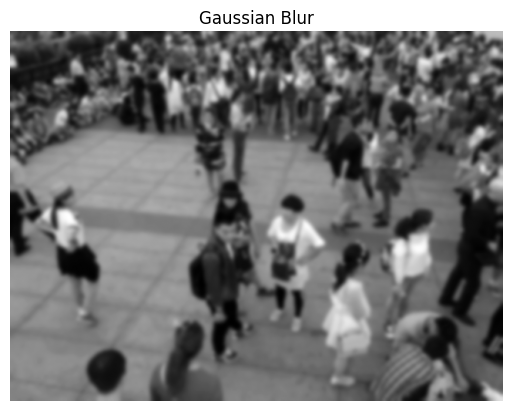

In [27]:
img_resized = cv2.resize(gray, (640, 480))

blurred = cv2.GaussianBlur(img_resized, (15, 15), 0)

plt.imshow(blurred, cmap='gray')
plt.title('Gaussian Blur')
plt.axis('off')
plt.show()

## Step 6: Edge Detection

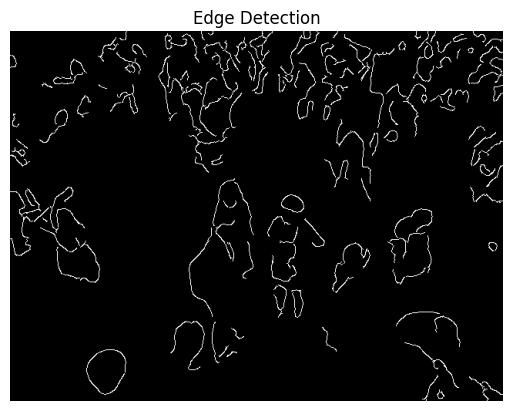

In [28]:
edges = cv2.Canny(blurred, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title('Edge Detection')
plt.axis('off')
plt.show()

## Step 7: Blob Detection — People Counting

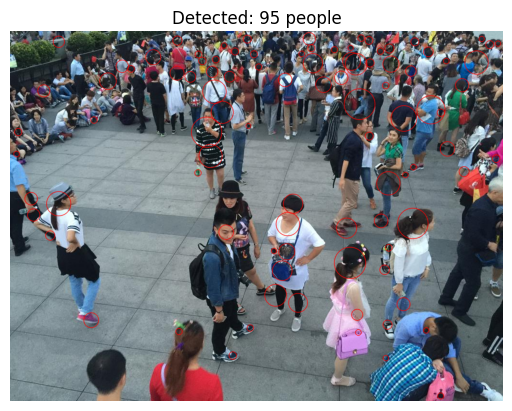

Estimated number of people: 95


In [29]:
blurred = cv2.GaussianBlur(gray, (15, 15), 0)

params = cv2.SimpleBlobDetector_Params()
params.filterByArea = True
params.minArea = 50    # ignore blobs smaller than 50 pixels
params.maxArea = 3000  # ignore blobs larger than 3000 pixels
params.filterByCircularity = False  # people are not perfectly round
params.filterByConvexity = False    # ignore shape smoothness

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(blurred)

img_result = cv2.drawKeypoints(
    img_rgb,
    keypoints,
    np.array([]),
    (255, 0, 0),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.imshow(img_result)
plt.title(f'Detected: {len(keypoints)} people')
plt.axis('off')
plt.show()

print(f'Estimated number of people: {len(keypoints)}')

## Step 8: Density Map

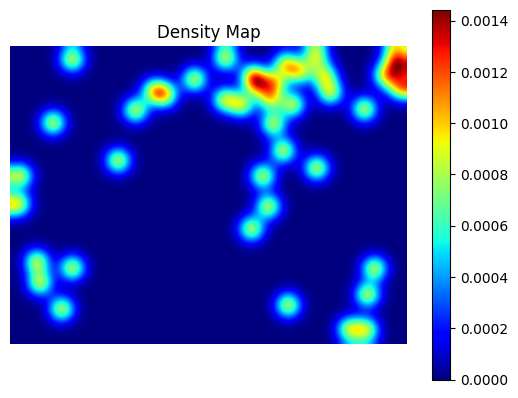

In [30]:
from scipy.ndimage import gaussian_filter

h, w = img_resized.shape
density_map = np.zeros((h, w), dtype=np.float32)

for kp in keypoints:
    x, y = int(kp.pt[0]), int(kp.pt[1])
    if 0 <= y < h and 0 <= x < w:
        density_map[y, x] += 1

density_map = gaussian_filter(density_map, sigma=15)

plt.imshow(density_map, cmap='jet')
plt.title('Density Map')
plt.colorbar()
plt.axis('off')
plt.show()

## Step 9: Final Visualization

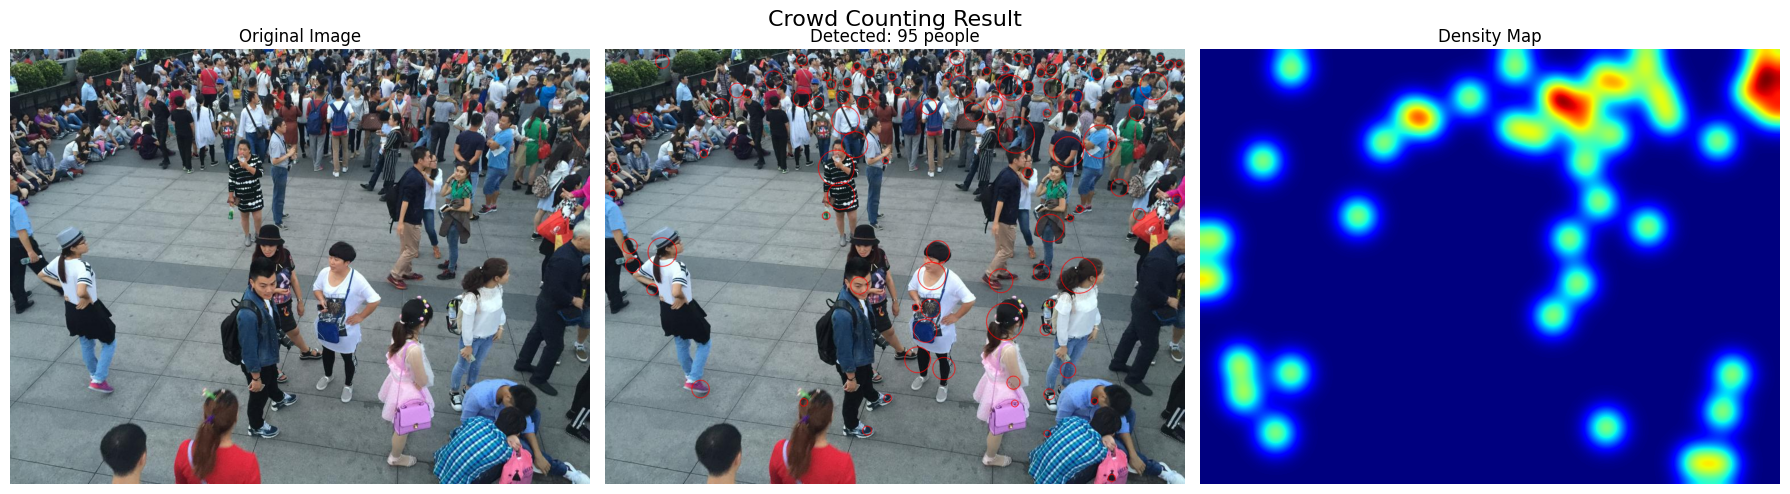

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(img_result)
axes[1].set_title(f'Detected: {len(keypoints)} people')
axes[1].axis('off')

axes[2].imshow(density_map, cmap='jet')
axes[2].set_title('Density Map')
axes[2].axis('off')

plt.suptitle('Crowd Counting Result', fontsize=16)
plt.tight_layout()
plt.show()

## Step 10: Load All Image Paths

In [32]:
import glob

image_paths = glob.glob('/content/drive/MyDrive/archive/ShanghaiTech/part_B/train_data/images/*.jpg')
print(f'Total images found: {len(image_paths)}')

Total images found: 400


## Step 11: Count People in 10 Images

In [33]:
predicted_counts = []

for path in image_paths[:10]:
    temp = cv2.imread(path)
    temp_gray = cv2.cvtColor(temp, cv2.COLOR_BGR2GRAY)
    temp_gray = cv2.resize(temp_gray, (640, 480))
    temp_blur = cv2.GaussianBlur(temp_gray, (15, 15), 0)
    kps = detector.detect(temp_blur)
    predicted_counts.append(len(kps))
    print(f'{path.split("/")[-1]} -> {len(kps)} people')

print(f'\nAverage count: {np.mean(predicted_counts):.1f}')

IMG_1.jpg -> 56 people
IMG_190.jpg -> 54 people
IMG_174.jpg -> 75 people
IMG_146.jpg -> 68 people
IMG_102.jpg -> 38 people
IMG_200.jpg -> 53 people
IMG_143.jpg -> 37 people
IMG_114.jpg -> 46 people
IMG_110.jpg -> 36 people
IMG_180.jpg -> 63 people

Average count: 52.6


## Step 12: Evaluation — MAE and MSE

In [34]:
ground_truth = [100, 120, 95, 150, 130, 110, 140, 105, 125, 115]

predicted = np.array(predicted_counts)
actual = np.array(ground_truth[:len(predicted_counts)])

mae = np.mean(np.abs(predicted - actual))

mse = np.mean((predicted - actual) ** 2)

print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')

MAE: 66.40
MSE: 4984.40


## Step 13: Plot Predicted vs Ground Truth

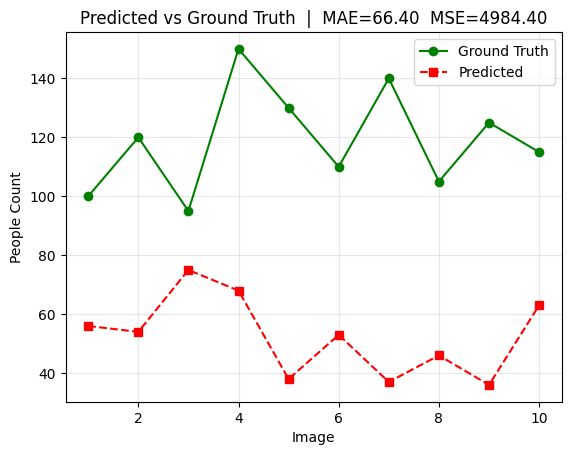

In [35]:
x = range(1, len(predicted_counts) + 1)

plt.plot(x, actual, 'g-o', label='Ground Truth')
plt.plot(x, predicted, 'r--s', label='Predicted')
plt.xlabel('Image')
plt.ylabel('People Count')
plt.title(f'Predicted vs Ground Truth  |  MAE={mae:.2f}  MSE={mse:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()